In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Helvetica Neue'

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/Action potential waveforms are state-dependent paper/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/')
import config
import importlib
import spk_feat_cluster_comp_analysis as sfca
importlib.reload(sfca)
from spk_feat_cluster_comp_analysis import (
    kde_panel_solid,
    plot_isi_independence_legend,
    plot_isi_independence_example,
    plot_eta2_population,
    plot_eta2_legend,
)

CLUSTER_PKL_DIR = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/'

# Wong (2011) 2-group palette: low=blue, high=pink (matches Fig 4B/C, Supp Fig 7-8, 10-11)
CLUST_COLORS = {'low': '#0072B2', 'high': '#CC79A7'}
EXAMPLE_CELL = 32

FEATS = [
    ('peak_amp',       'Peak\namplitude',         False),
    ('peak_sharpness', 'Peak\nsharpness',          False),
    ('exp_const',      'Repolarization\nconstant', False),
    ('log_isi',        'Log ISI',                  True),
]

Supplementary Figure X. Spike waveform clusters are independent of ISI-based clusters.

(A) Feature distributions for an example cell (c32, n = 2887 spikes), shown as solid-fill kernel density estimates (IQR × 3 outlier removal, Scott's rule bandwidth, proportional normalization). Row 1: spikes colored by peak amplitude cluster assignment (low cluster, blue; high cluster, orange). Waveform features (peak amplitude, peak sharpness, repolarization constant) are clearly separated between cluster groups; log inter-spike interval (log ISI; grey background) is not. Row 2: same spikes colored by ISI cluster assignment. Log ISI is clearly separated; waveform features are not.

(B) Population distribution of η² (Kruskal-Wallis H / (n − 1)) quantifying the association between waveform cluster assignment and log ISI across all cells with at least one waveform cluster and an ISI cluster (n = XX cells). Dashed line: population median. Dotted line: c32. η² near 0 indicates that waveform cluster membership does not explain ISI variability.

In [2]:
# ── Load cluster pickles ──────────────────────────────────────────────────────
NO_CLUSTER = [17, 18, 43]

cell_dfs = {}
for cnum in list(config.DICT_CELL_TYPE.keys()):
    if cnum in NO_CLUSTER:
        continue
    pkl = os.path.join(CLUSTER_PKL_DIR, f'c{cnum}_cluster_df.pkl')
    if not os.path.exists(pkl):
        continue
    df = pd.read_pickle(pkl)
    if 'log_isi' not in df.columns:
        continue
    # Accept any cell with at least one waveform cluster column
    wf_cols = [c for c in df.columns if c.endswith('_cluster') and c != 'log_isi_cluster']
    if not wf_cols and 'groups' not in df.columns:
        continue
    cell_dfs[cnum] = df

print(f'Cells loaded: {len(cell_dfs)}')

df_ex  = cell_dfs[EXAMPLE_CELL]
wclust = 'peak_amp_cluster' if 'peak_amp_cluster' in df_ex.columns else 'groups'
iclust = 'log_isi_cluster'
print(f'c{EXAMPLE_CELL}: wclust={wclust}, iclust={iclust}')

Cells loaded: 34
c32: wclust=peak_amp_cluster, iclust=log_isi_cluster


In [3]:
# ── Population η²: log ISI ~ waveform cluster (any waveform cluster) ──────────
from scipy.stats import kruskal

results = []
for cnum, df in cell_dfs.items():
    sub = df.dropna(subset=['log_isi'])
    # Use groups if present, otherwise first available waveform cluster column
    if 'groups' in sub.columns:
        wcol = 'groups'
    else:
        wf_cols = [c for c in sub.columns if c.endswith('_cluster') and c != 'log_isi_cluster']
        wcol = wf_cols[0] if wf_cols else None
    if wcol is None:
        continue
    sub    = sub.dropna(subset=[wcol])
    groups = [g for g in sub[wcol].unique() if len(sub[sub[wcol] == g]) >= 2]
    if len(groups) < 2:
        continue
    grp_data = [sub.loc[sub[wcol] == g, 'log_isi'].values for g in groups]
    n        = sum(len(g) for g in grp_data)
    H, _     = kruskal(*grp_data)
    results.append({'cell': cnum, 'waveform_cluster_col': wcol, 'eta2': H / (n - 1), 'n': n})

df_eta = pd.DataFrame(results).sort_values('cell').reset_index(drop=True)
print(f'n cells: {len(df_eta)}   Median η² = {df_eta.eta2.median():.3f}')
print(f'c{EXAMPLE_CELL} η² = {df_eta.loc[df_eta.cell == EXAMPLE_CELL, "eta2"].values[0]:.3f}')
print(df_eta[['cell', 'waveform_cluster_col', 'eta2']].to_string())

n cells: 33   Median η² = 0.013
c32 η² = 0.016
    cell     waveform_cluster_col      eta2
0      1         peak_amp_cluster  0.075262
1      2       exp_lambda_cluster  0.000041
2      3         peak_amp_cluster  0.071476
3      4         peak_amp_cluster  0.043381
4      5  inflection_time_cluster  0.000383
5      6       peak_width_cluster  0.012682
6      7  inflection_time_cluster  0.045501
7      8       peak_width_cluster  0.016794
8     10         peak_amp_cluster  0.005049
9     12       peak_width_cluster  0.000124
10    14   peak_sharpness_cluster  0.013487
11    15       peak_width_cluster  0.000493
12    19   peak_sharpness_cluster  0.001846
13    20         peak_amp_cluster  0.029970
14    21         peak_amp_cluster  0.030783
15    22  inflection_time_cluster  0.020563
16    23       peak_width_cluster  0.048969
17    24       peak_width_cluster  0.007507
18    25  inflection_time_cluster  0.056847
19    27   inflection_amp_cluster  0.006183
20    28       peak_width_clu

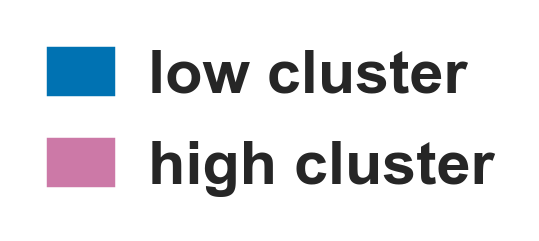

In [4]:
# ── Legend (separate) ─────────────────────────────────────────────────────────
fig_leg = plot_isi_independence_legend(CLUST_COLORS, fontsize=22)
plt.show()

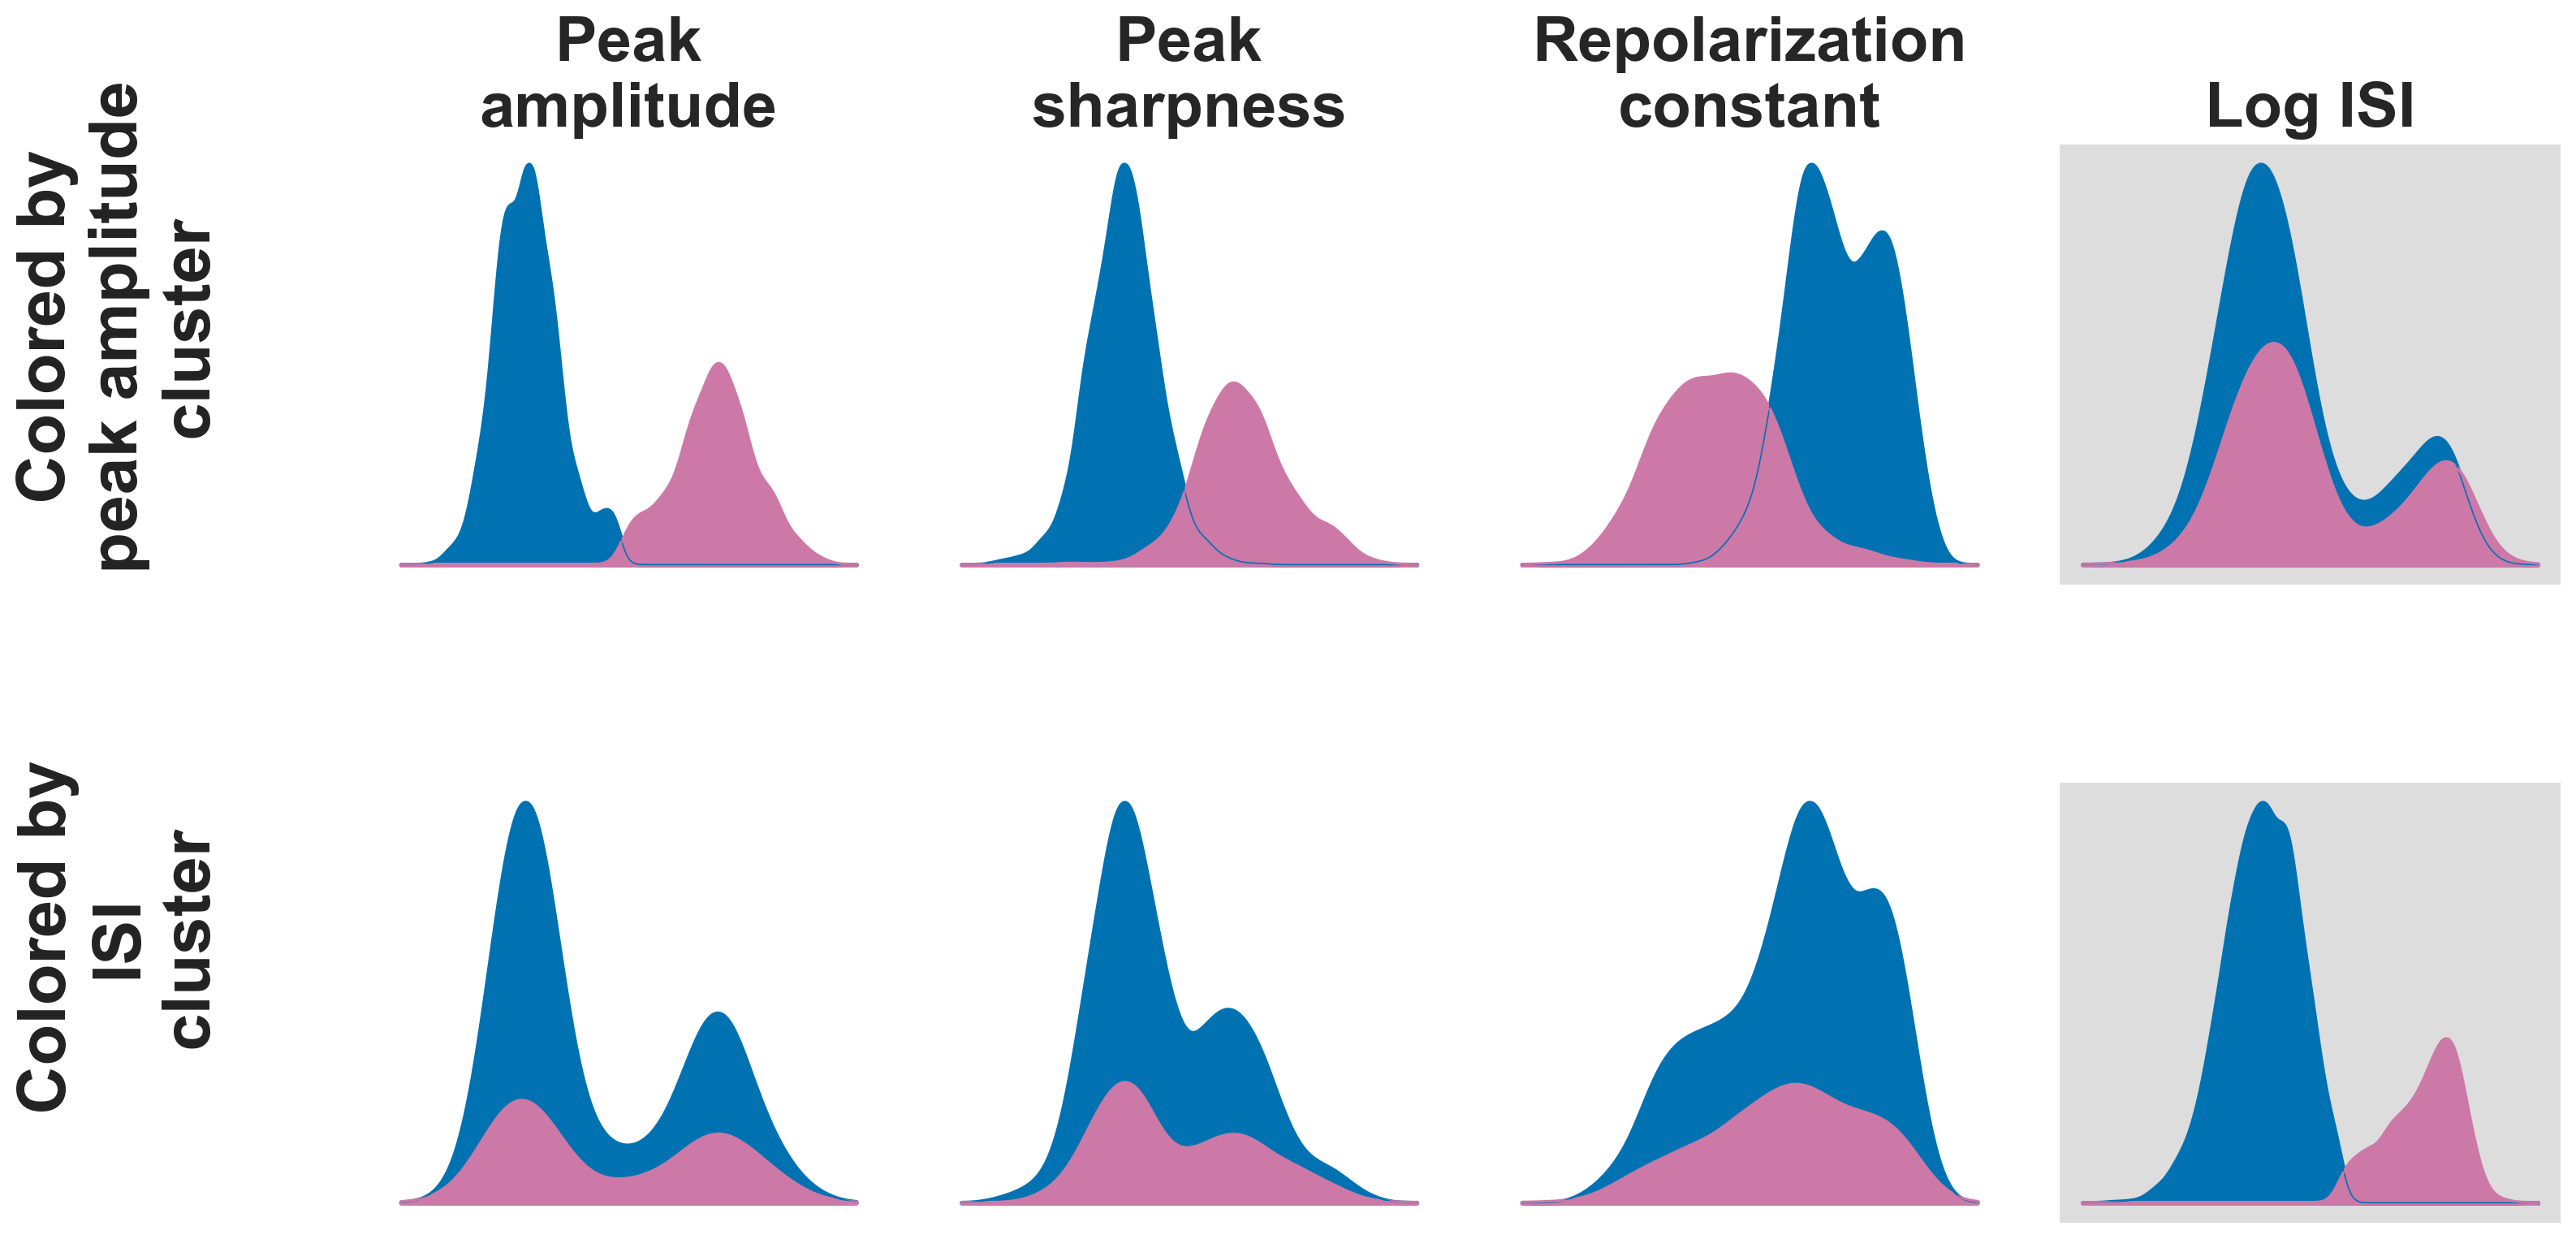

In [5]:
# ── c32 example: waveform vs ISI cluster ──────────────────────────────────────
fig_ex = plot_isi_independence_example(
    df_ex, wclust, iclust, FEATS, CLUST_COLORS,
    col_label_fs=28, row_label_fs=30,
    figsize=(16, 8),
)
plt.show()

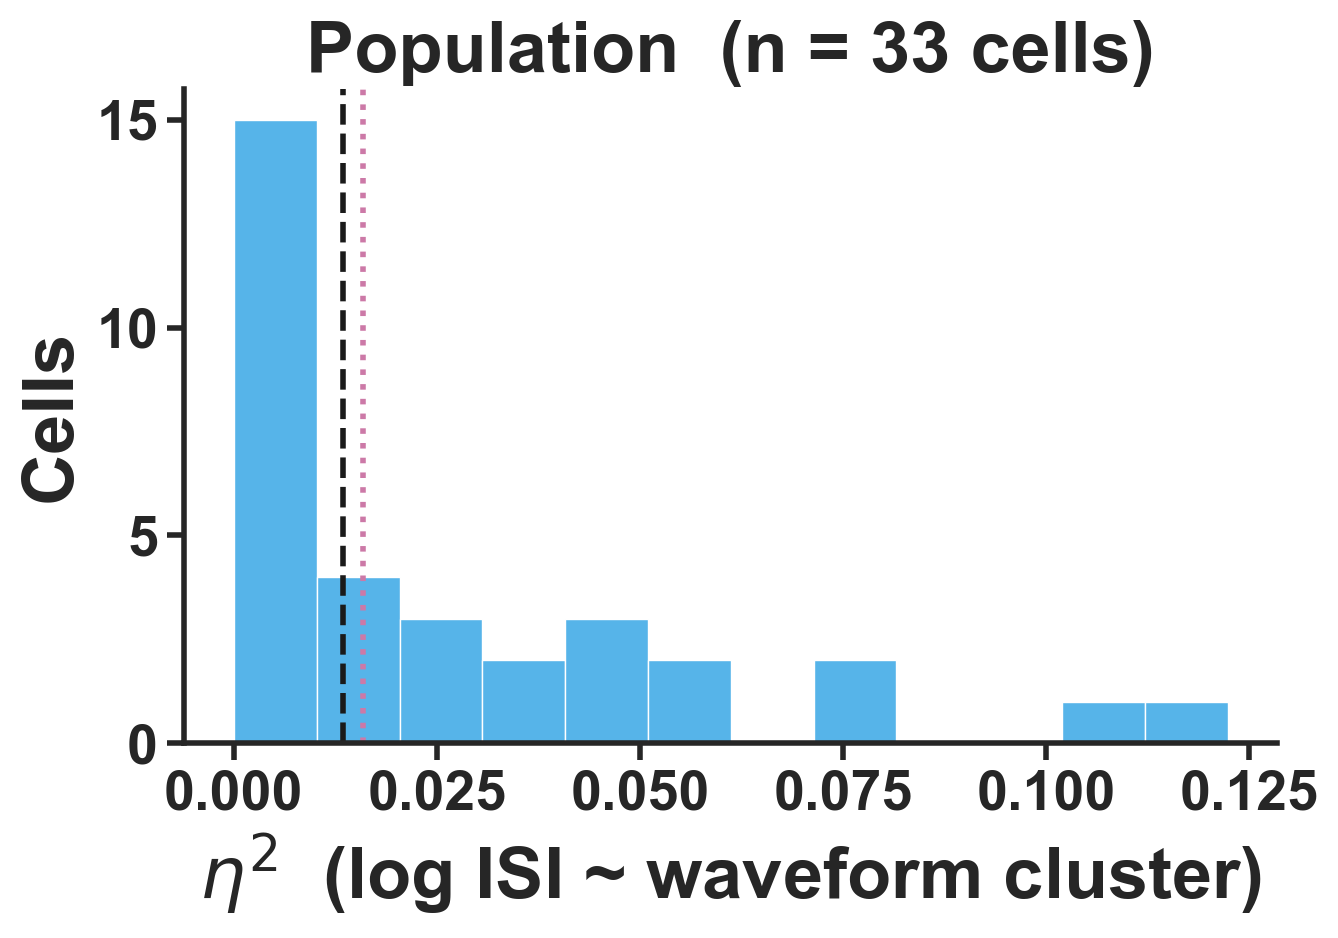

In [6]:
# ── Population η² histogram ───────────────────────────────────────────────────
fig_pop, med_eta2, ex_eta2 = plot_eta2_population(
    df_eta, EXAMPLE_CELL, CLUST_COLORS,
    fs_ax=26, fs_tk=20, lw_sp=2.0,
    figsize=(7, 5),
)
plt.show()

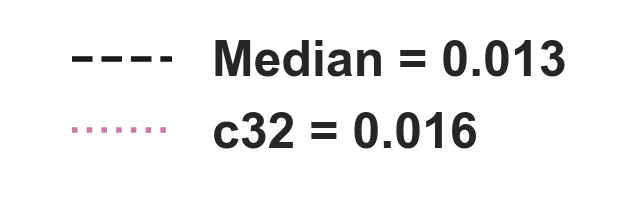

In [7]:
# ── Population legend (separate) ──────────────────────────────────────────────
fig_pop_leg = plot_eta2_legend(med_eta2, ex_eta2, EXAMPLE_CELL, CLUST_COLORS, fontsize=18)
plt.show()

---
## Preceding-ISI version

The panels above use `log_isi` (time to the **next** spike). But a backward-looking mechanism - refractoriness and accommodation depending on the interval **before** a spike - is more directly tested with the preceding interval. Repeating the same analysis against `log_isi_prev` below, unchanged otherwise. Both versions are kept side by side; nothing above was modified.

In [8]:
# ── Population eta2: log_isi_prev ~ waveform cluster (parallels the log_isi cell above) ──
results_prev = []
for cnum, df in cell_dfs.items():
    if 'log_isi_prev' not in df.columns:
        continue
    sub = df.dropna(subset=['log_isi_prev'])
    if 'groups' in sub.columns:
        wcol = 'groups'
    else:
        wf_cols = [c for c in sub.columns if c.endswith('_cluster') and c != 'log_isi_cluster']
        wcol = wf_cols[0] if wf_cols else None
    if wcol is None:
        continue
    sub    = sub.dropna(subset=[wcol])
    groups = [g for g in sub[wcol].unique() if len(sub[sub[wcol] == g]) >= 2]
    if len(groups) < 2:
        continue
    grp_data = [sub.loc[sub[wcol] == g, 'log_isi_prev'].values for g in groups]
    n        = sum(len(g) for g in grp_data)
    H, _     = kruskal(*grp_data)
    results_prev.append({'cell': cnum, 'waveform_cluster_col': wcol, 'eta2': H / (n - 1), 'n': n})

df_eta_prev = pd.DataFrame(results_prev).sort_values('cell').reset_index(drop=True)
print(f'n cells: {len(df_eta_prev)}   Median eta2 (preceding ISI) = {df_eta_prev.eta2.median():.4f}')
print(f'  (for reference, next-ISI median above was {df_eta.eta2.median():.4f})')
print(f'c{EXAMPLE_CELL} eta2 (preceding ISI) = '
      f'{df_eta_prev.loc[df_eta_prev.cell == EXAMPLE_CELL, "eta2"].values[0]:.3f}')


n cells: 33   Median eta2 (preceding ISI) = 0.0555
  (for reference, next-ISI median above was 0.0135)
c32 eta2 (preceding ISI) = 0.021


In [9]:
# ── Per-cell comparison: next vs preceding ──────────────────────────────
df_eta_compare = df_eta[['cell', 'eta2']].merge(
    df_eta_prev[['cell', 'eta2']], on='cell', suffixes=('_next', '_prev')
).sort_values('eta2_prev', ascending=False).reset_index(drop=True)
n_up = (df_eta_compare.eta2_prev > df_eta_compare.eta2_next).sum()
n_med_next = (df_eta_compare.eta2_next >= 0.06).sum()
n_med_prev = (df_eta_compare.eta2_prev >= 0.06).sum()
print(f'Cells where preceding-ISI eta2 > next-ISI eta2: {n_up} / {len(df_eta_compare)}')
print(f'Cells with eta2 >= 0.06 (medium+): next-ISI {n_med_next}, preceding-ISI {n_med_prev}')
df_eta_compare

Cells where preceding-ISI eta2 > next-ISI eta2: 24 / 33
Cells with eta2 >= 0.06 (medium+): next-ISI 4, preceding-ISI 16


,cell,eta2_next,eta2_prev
0,8,0.016794,0.327955
1,10,0.005049,0.313889
2,45,0.122356,0.274198
3,14,0.013487,0.210357
4,31,0.000408,0.145627
5,12,0.000124,0.142086
6,6,0.012682,0.125006
7,33,0.007205,0.113946
8,39,0.103537,0.111095
9,25,0.056847,0.107236


### c32 example, preceding ISI
Same panel as the next-ISI example above (Fig A), with `log_isi` swapped for `log_isi_prev` throughout - **including row 2's cluster assignment**, which needed its own clustering step (a first pass here reused the next-ISI cluster column by mistake, mislabeled as if it were a preceding-ISI cluster - fixed below).

True {'low': 2122, 'high': 710, nan: 55}


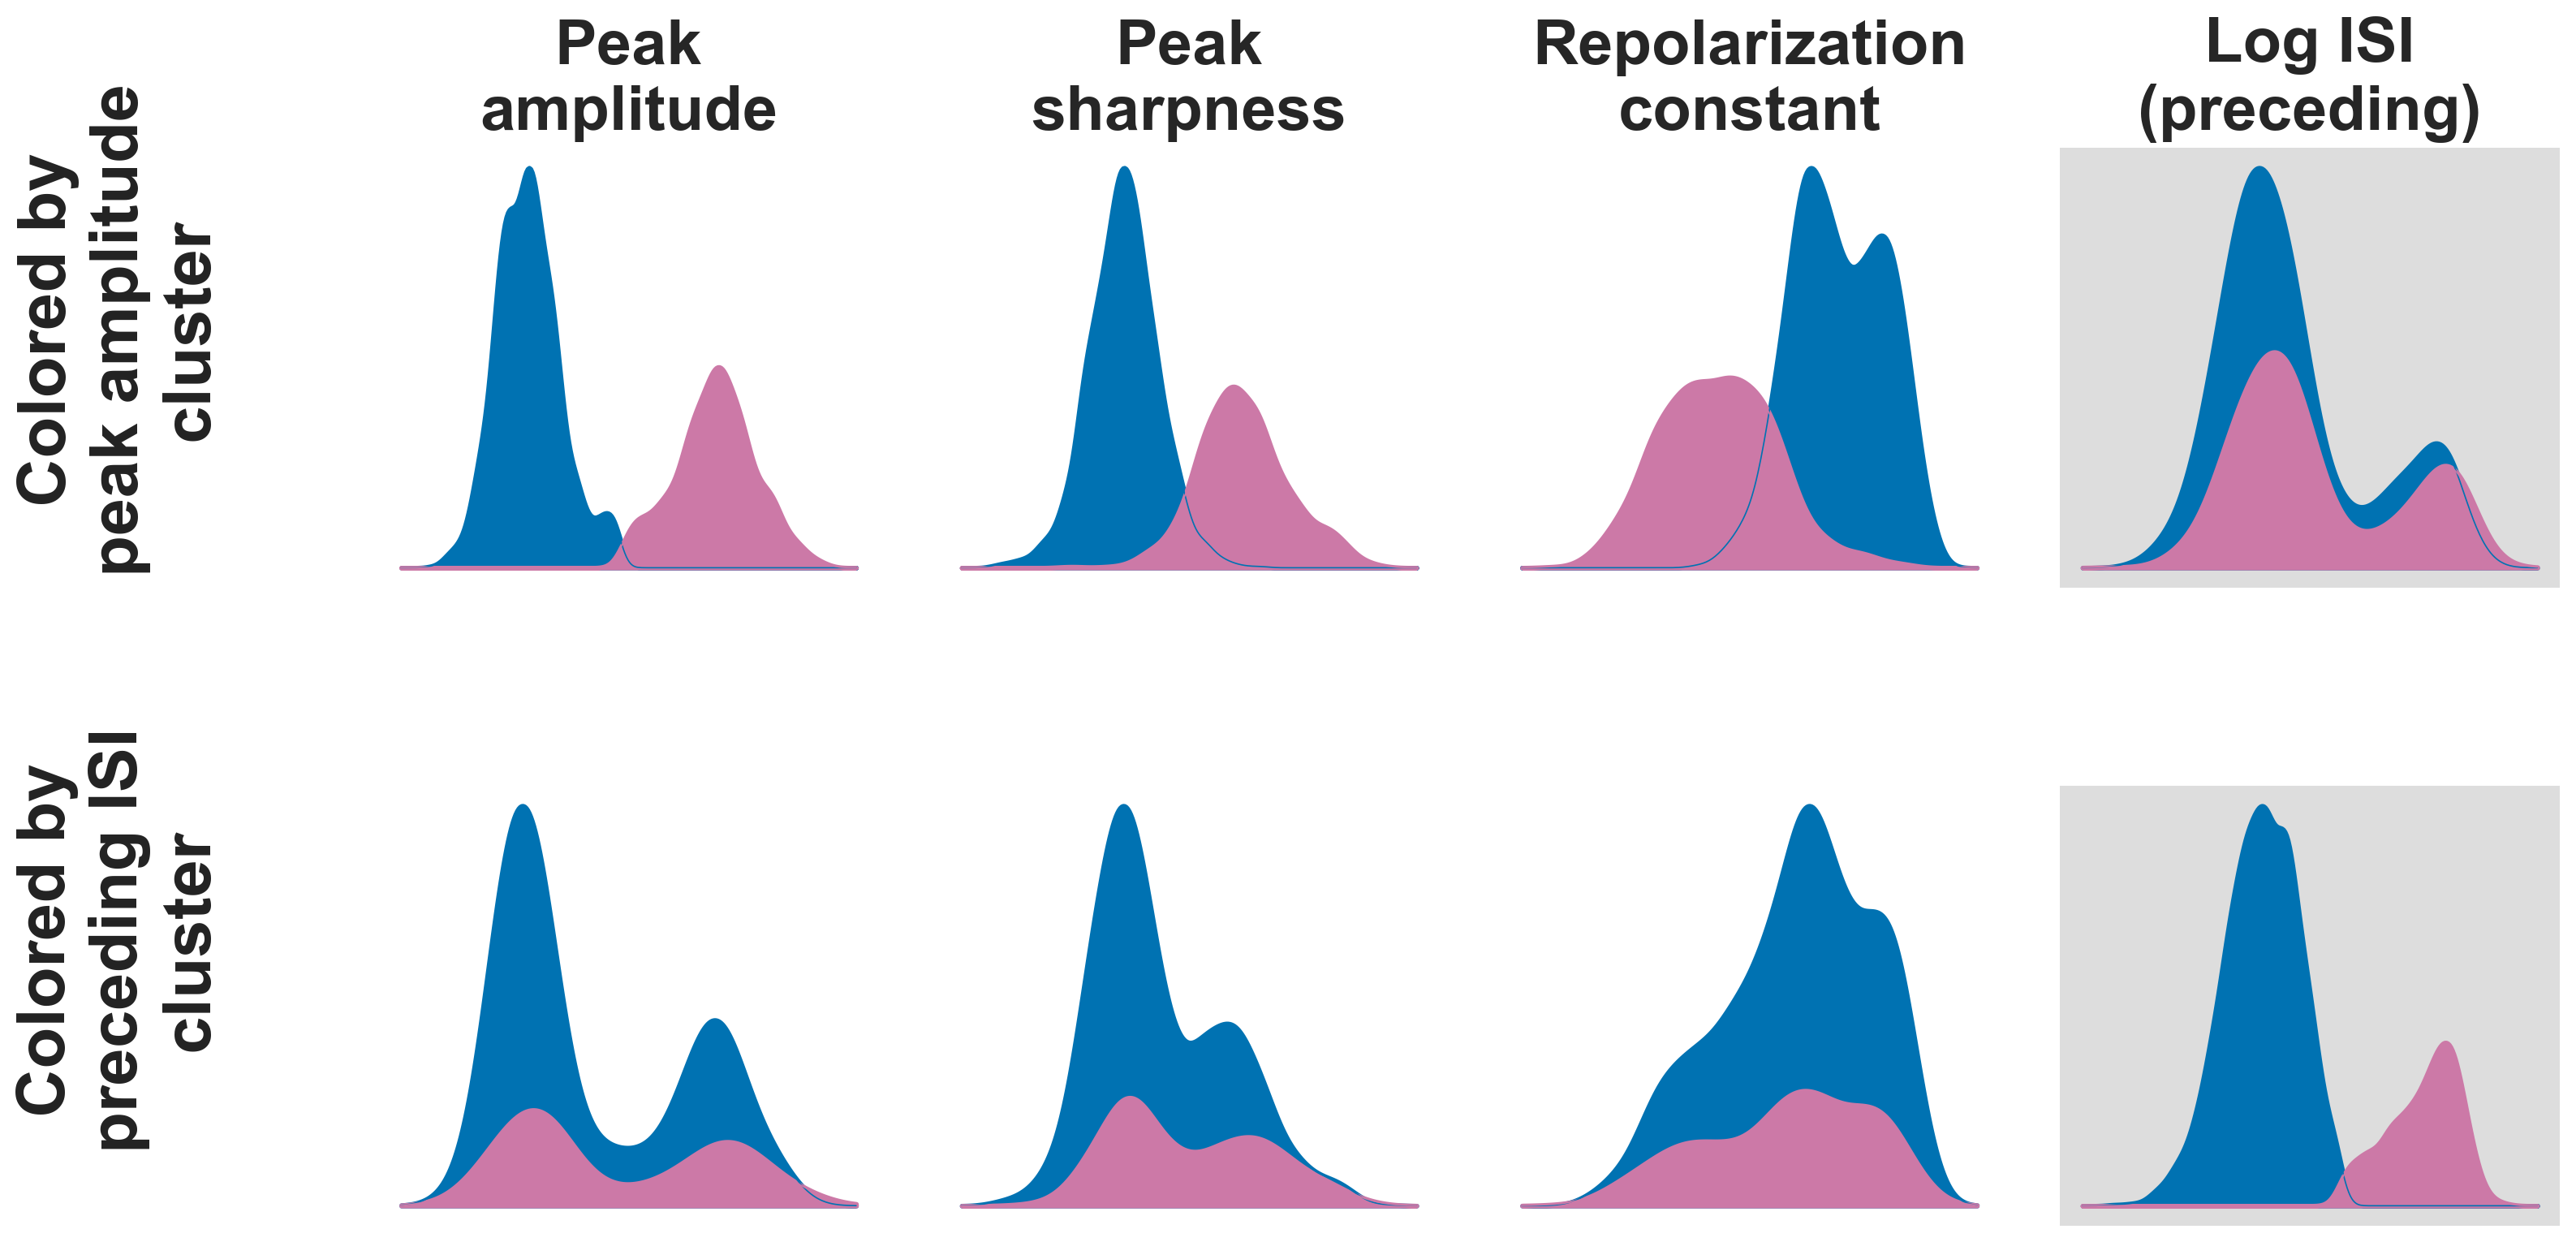

In [10]:
from spk_feat_cluster_analysis import cluster_multimodal_features

# Row 2 needs an actual preceding-ISI cluster, not a reuse of log_isi_cluster
# (next-ISI) - same clustering function/params used to build log_isi_cluster
# originally, just restricted to log_isi_prev.
df_ex_prev, _ = cluster_multimodal_features(
    df_ex, features=['log_isi_prev'], max_k=2, suffix='_cluster', plot_each=False,
)
iclust_prev = 'log_isi_prev_cluster'
print('log_isi_prev_cluster' in df_ex_prev.columns,
      df_ex_prev['log_isi_prev_cluster'].value_counts(dropna=False).to_dict())

FEATS_PREV = [f if f[0] != 'log_isi' else ('log_isi_prev', 'Log ISI\n(preceding)', True) for f in FEATS]

fig_ex_prev = plot_isi_independence_example(
    df_ex_prev, wclust, iclust_prev, FEATS_PREV, CLUST_COLORS,
    col_label_fs=28, row_label_fs=30,
    figsize=(16, 8),
    row2_label='Colored by\npreceding ISI\ncluster',
)
plt.show()

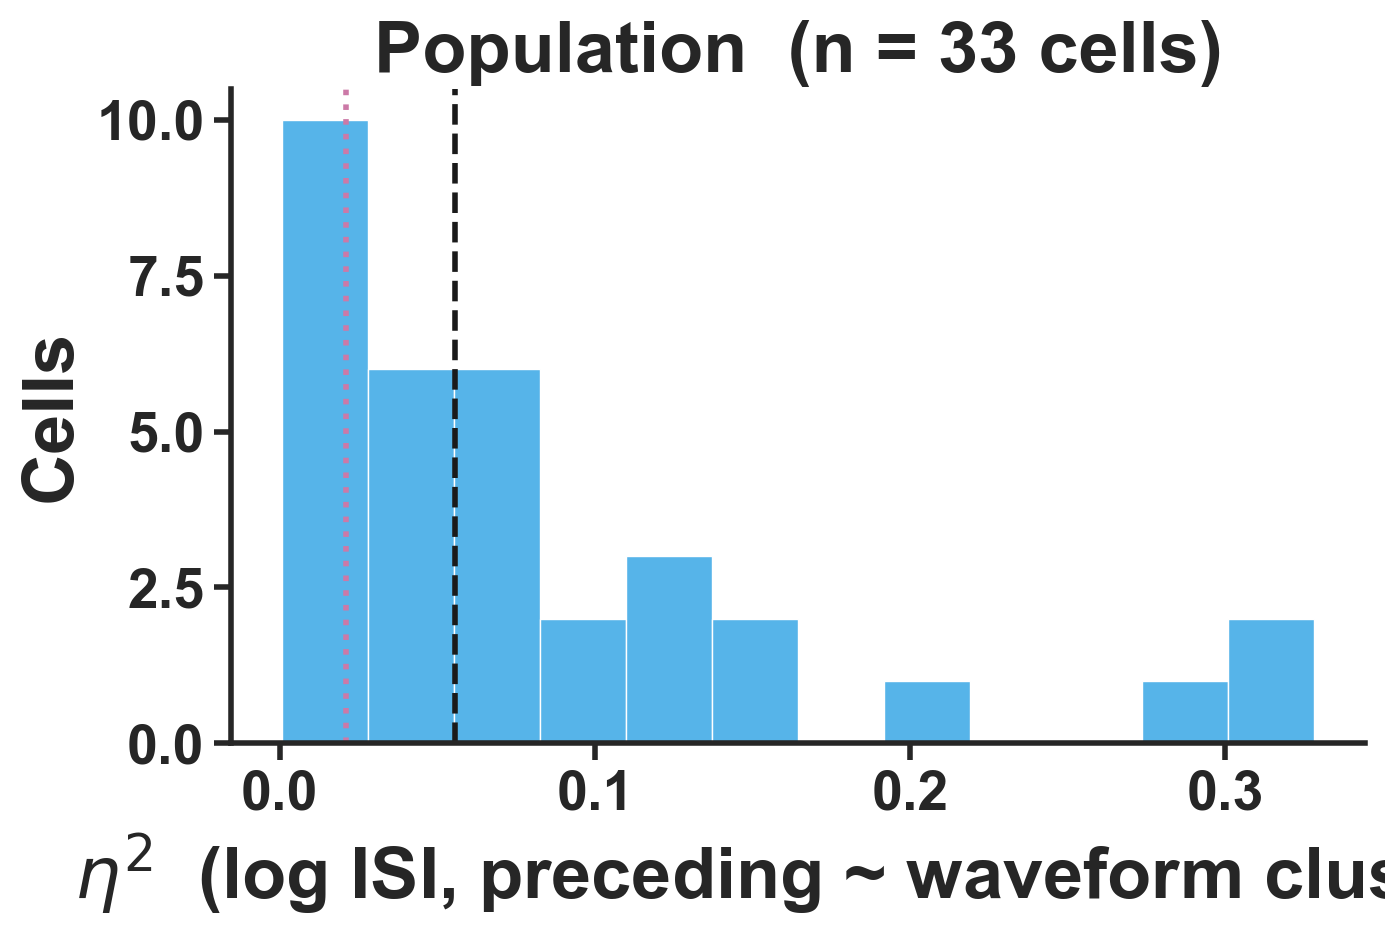

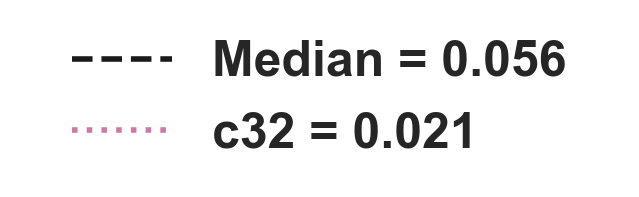

In [11]:
# ── Population eta2 histogram, preceding ISI (parallels Panel B above) ──
fig_pop_prev, med_eta2_prev, ex_eta2_prev = plot_eta2_population(
    df_eta_prev, EXAMPLE_CELL, CLUST_COLORS,
    fs_ax=26, fs_tk=20, lw_sp=2.0,
    figsize=(7, 5),
)
fig_pop_prev.axes[0].set_xlabel(r'$\eta^2$  (log ISI, preceding ~ waveform cluster)', fontsize=26, fontweight='bold')
plt.show()

fig_pop_leg_prev = plot_eta2_legend(med_eta2_prev, ex_eta2_prev, EXAMPLE_CELL, CLUST_COLORS, fontsize=18)
plt.show()

---
## Second example: c8 (largest next→preceding swing)

c32 above was kept as the example cell because it's what the original published figure used, but its η² barely moves (0.016→0.021) - it's near the bottom of the whole distribution, not representative of the population shift. c8 is the opposite end: η² goes from 0.017 (next ISI, unremarkable) to 0.328 (preceding ISI, the largest single-cell effect in the set). Same panel layout as c32, both ISI directions shown for direct contrast.

In [12]:
EXAMPLE_CELL_2 = 8
df_ex2  = cell_dfs[EXAMPLE_CELL_2]
wclust2 = next((c for c in df_ex2.columns if c.endswith('_cluster') and c != 'log_isi_cluster'), None)
wclust2_label = wclust2.replace('_cluster', '').replace('_', ' ')
print(f'c{EXAMPLE_CELL_2}: wclust={wclust2}, n={len(df_ex2)}')
print(df_ex2[wclust2].value_counts(dropna=False))

# peak_width_cluster for c8 is a genuine 3-group split (low/mid/high), unlike
# c32's clean low/high - CLUST_COLORS only defines 2 colors, so extend it here
# rather than let the 3rd group silently render as an unlabeled gray fallback.
CLUST_COLORS_C8 = dict(CLUST_COLORS)
CLUST_COLORS_C8['mid'] = '#2ca02c'  # matches the low/mid/high convention used elsewhere in this codebase

FEATS_C8 = [
    ('peak_width',     'Peak\nwidth',             False),
    ('peak_sharpness', 'Peak\nsharpness',          False),
    ('exp_lambda',     'Decay\nrate',              False),
    ('log_isi',        'Log ISI\n(next)',          True),
]

c8: wclust=peak_width_cluster, n=4881
mid     2233
low     1347
high    1301
Name: peak_width_cluster, dtype: int64


### c8 example, next ISI

c8 eta2 (next ISI) = 0.017


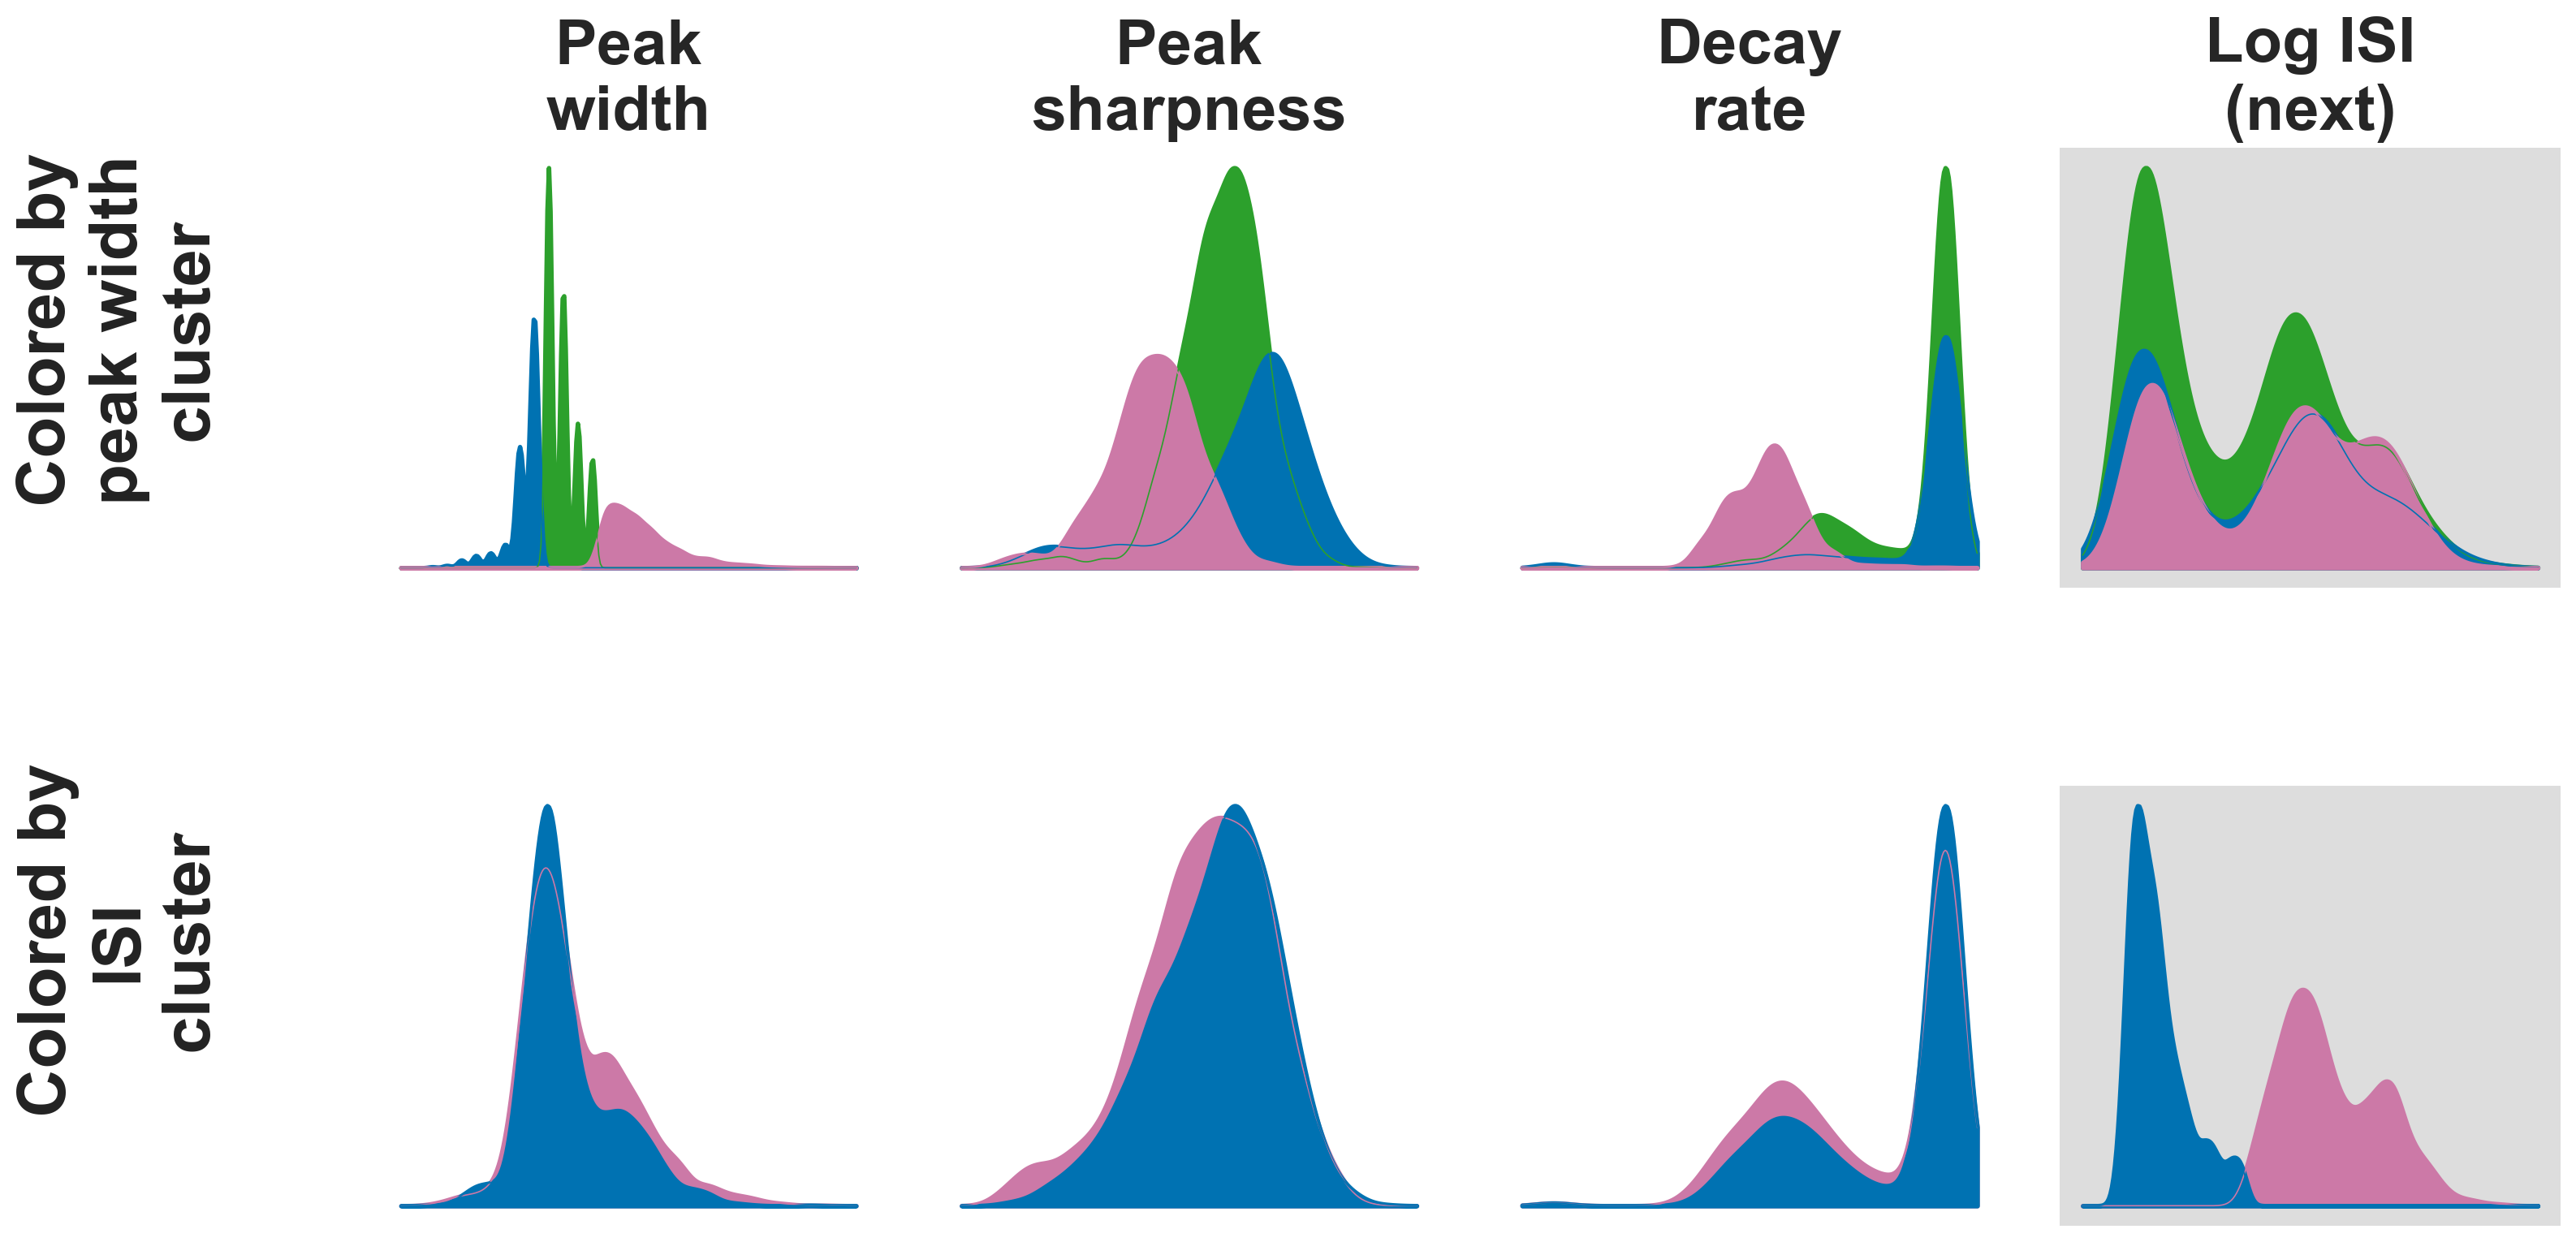

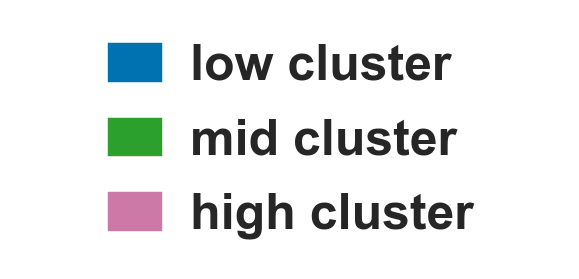

In [13]:
fig_ex2_next = plot_isi_independence_example(
    df_ex2, wclust2, 'log_isi_cluster', FEATS_C8, CLUST_COLORS_C8,
    col_label_fs=28, row_label_fs=30,
    figsize=(16, 8),
    row1_label=f'Colored by\n{wclust2_label}\ncluster',
)
eta2_c8_next = df_eta.loc[df_eta.cell == EXAMPLE_CELL_2, 'eta2'].values[0]
print(f'c{EXAMPLE_CELL_2} eta2 (next ISI) = {eta2_c8_next:.3f}')
plt.show()

# 3-entry legend (low/mid/high) since this cluster isn't the standard 2-group case
from matplotlib.patches import Patch as _Patch
_handles = [_Patch(facecolor=CLUST_COLORS_C8[g], label=f'{g} cluster') for g in ['low', 'mid', 'high']]
_fig_leg, _ax_leg = plt.subplots(figsize=(3.2, 1.4))
_ax_leg.axis('off')
_ax_leg.legend(handles=_handles, loc='center', ncol=1, frameon=False,
               handlelength=1.2, handleheight=1.0, handletextpad=0.5,
               prop={'weight': 'bold', 'size': 18})
_fig_leg.tight_layout()
plt.show()

### c8 example, preceding ISI

c8 eta2 (preceding ISI) = 0.328


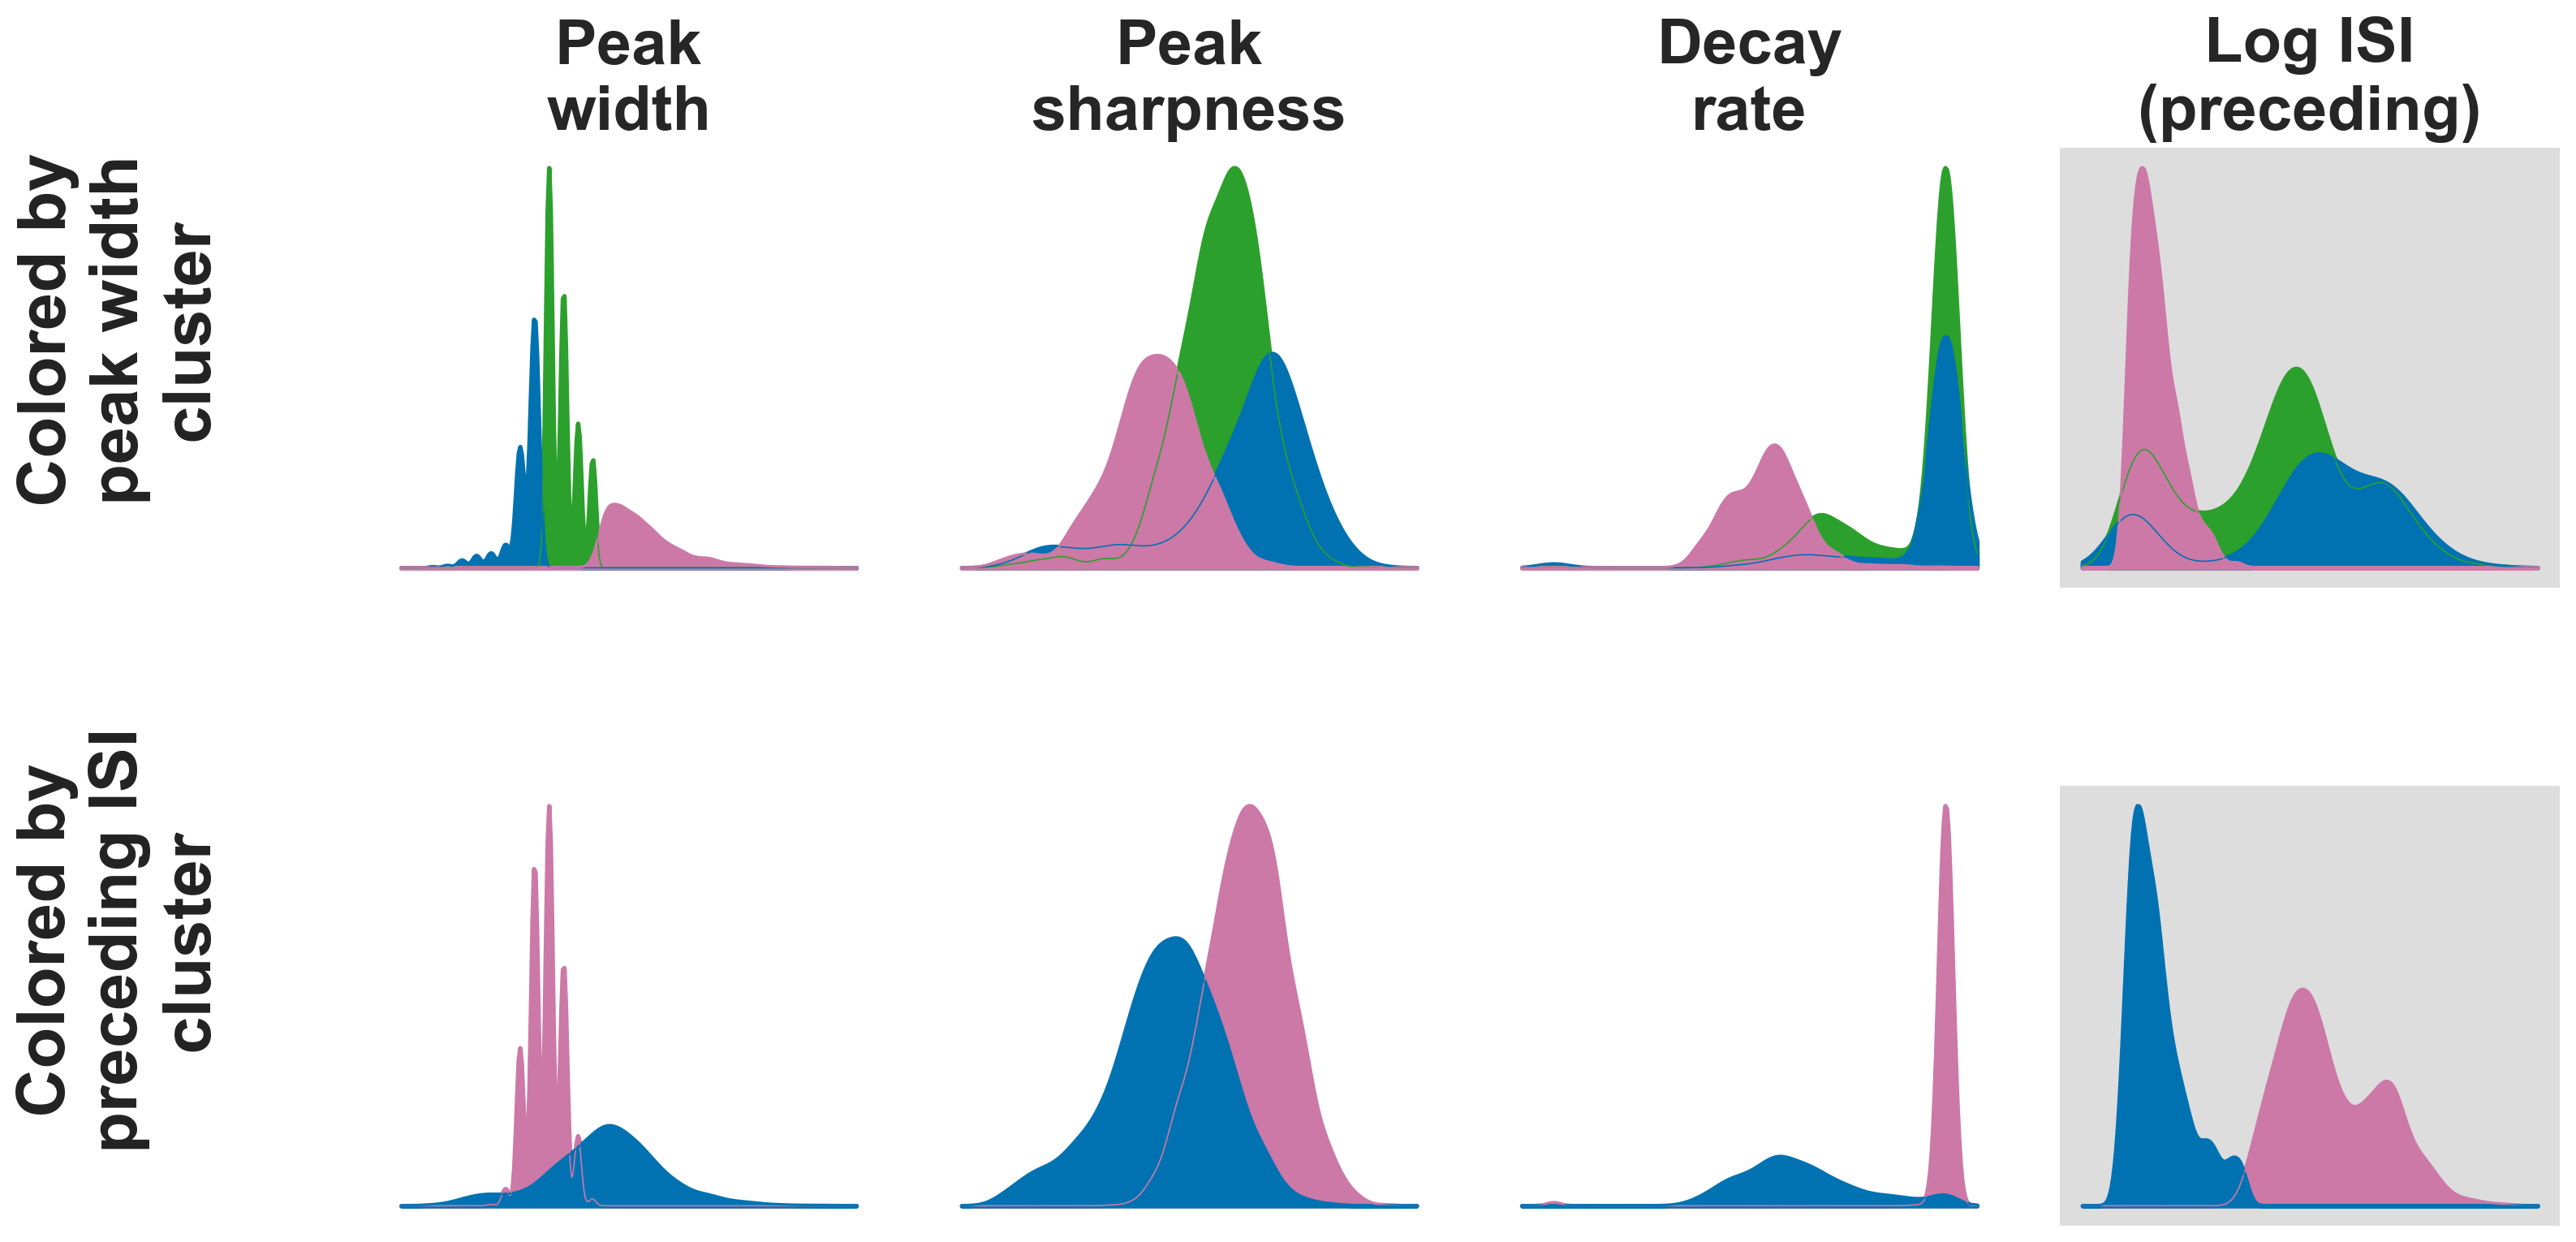

In [14]:
df_ex2_prev, _ = cluster_multimodal_features(
    df_ex2, features=['log_isi_prev'], max_k=2, suffix='_cluster', plot_each=False,
)

FEATS_C8_PREV = [f if f[0] != 'log_isi' else ('log_isi_prev', 'Log ISI\n(preceding)', True) for f in FEATS_C8]

fig_ex2_prev = plot_isi_independence_example(
    df_ex2_prev, wclust2, 'log_isi_prev_cluster', FEATS_C8_PREV, CLUST_COLORS_C8,
    col_label_fs=28, row_label_fs=30,
    figsize=(16, 8),
    row1_label=f'Colored by\n{wclust2_label}\ncluster',
    row2_label='Colored by\npreceding ISI\ncluster',
)
eta2_c8_prev = df_eta_prev.loc[df_eta_prev.cell == EXAMPLE_CELL_2, 'eta2'].values[0]
print(f'c{EXAMPLE_CELL_2} eta2 (preceding ISI) = {eta2_c8_prev:.3f}')
plt.show()

---
## Reframing the claim

The population median (0.0135 → 0.0555) isn't the right summary for what's actually being tested here. The strong, universal form of the claim under test is that waveform variation "may be nothing more than a downstream readout of spike history... carries no information beyond the spike times we already have." That predicts *every* cell's waveform clustering should track preceding ISI, since by hypothesis nothing else is available to drive it.

That's not what the population shows. A substantial fraction of cells show waveform clustering with essentially no measurable relationship to preceding ISI - which is the direct counterexample to "nothing more than" being universally true, independent of what the rest of the distribution is doing.

In [15]:
n_below_03 = (df_eta_prev.eta2 < 0.03).sum()
n_below_01 = (df_eta_prev.eta2 < 0.01).sum()
n_total = len(df_eta_prev)

print(f'eta2 < 0.03 (well under even a \'small\' effect): {n_below_03} / {n_total} cells '
      f'({100*n_below_03/n_total:.0f}%)')
print(f'eta2 < 0.01 (essentially zero measurable coupling): {n_below_01} / {n_total} cells '
      f'({100*n_below_01/n_total:.0f}%)')

eta2 < 0.03 (well under even a 'small' effect): 11 / 33 cells (33%)
eta2 < 0.01 (essentially zero measurable coupling): 4 / 33 cells (12%)


**The claim this data actually supports:** not "waveform and ISI are independent" (too strong - a real minority of cells show medium-to-large coupling, e.g. c8 at 0.328, c10 at 0.314, c45 at 0.274, plausibly reflecting burst-structure-dependent effects worth acknowledging rather than explaining away). And not "waveform is nothing more than spike history" either (also too strong - contradicted directly by the cells above with near-zero coupling, which have no mechanism left to produce clean waveform clusters under that hypothesis).

What holds up: a substantial fraction of cells show waveform clustering with essentially no preceding-ISI signature, which is inconsistent with the strong deflationary claim above - even though a real minority of cells do show meaningful coupling that shouldn't be swept under the rug. The honest picture is heterogeneity, not a clean verdict in either direction, and the heterogeneous-coupling half is itself consistent with a burst-structure mechanism operating unevenly across cells rather than uniformly.